# **Deep Learning for Image Classification**

**Proyecto:** Portafolio (Análisis e Implementación) - Implementación de un modelo de deep learning  
**Módulo:** 2  
**Profesor:** Julio Guillermo Arriaga Blumenkron  
**Fecha de entrega:** 11 de noviembre de 2025  

---

### Realizado por:
**Ulises Jaramillo Portilla** — *Matrícula:* A01798380

---

---

# **Introducción**

---
Este proyecto implementa un pipeline completo de Computer Vision para entrenar un modelo de clasificación de escenas utilizando el dataset ***Intel Image Classification***. Se emplea un enfoque basado en transfer learning con ***EfficientNetB0***, preentrenado en ImageNet, complementado con técnicas de data augmentation, fine-tuning y evaluación cuantitativa mediante métricas estándar. El flujo abarca desde la adquisición del dataset mediante la API de Kaggle, la estructuración de los datos en splits, la construcción del modelo, entrenamiento en dos etapas y evaluación final, hasta la inferencia con imágenes nuevas.


---
## **Problemática encontrada a resolver**

En un escenario real, este tipo de sistema puede utilizarse para automatizar la clasificación de imágenes en plataformas de turismo, análisis ambiental, herramientas de monitoreo satelital, o incluso en aplicaciones móviles que organizan fotos por categorías. El problema que se busca resolver es la clasificación eficiente y precisa de grandes cantidades de imágenes, reduciendo el trabajo manual y permitiendo que empresas o instituciones tomen decisiones más rápidas basadas en la información visual.

---



## **Solución implementada**
---



### **Instalación de dependencias**

En esta parte se instalan todas las librerías necesarias para el proyecto, incluyendo TensorFlow para el modelado, Kaggle para descargar el dataset, y herramientas útiles como pandas, numpy y scikit-learn. Esto prepara el entorno de Google Colab para ejecutar el resto del código sin errores.

In [13]:
!pip install -q kaggle tensorflow matplotlib pandas numpy scikit-learn tqdm

### **Configurar API de Kaggle**

Aquí se sube el archivo kaggle.json, que contiene las credenciales necesarias para utilizar la API de Kaggle.

 ***Sin este paso no es posible descargar datasets automáticamente desde la plataforma.***

In [14]:
# Descarga tu kaggle.json desde https://www.kaggle.com/settings (API/Create Legacy API Key)
from google.colab import files
files.upload()  # selecciona kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ulisesjpx","key":"5f3eb1180cf8f531a90fa034ac935607"}'}

### **Mover credenciales y permisos**

En esta sección se colocan las credenciales de Kaggle en la ruta donde Colab puede usarlas y se ajustan los permisos del archivo. Esto permite autenticar correctamente las descargas.

In [15]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Credenciales de Kaggle configuradas.")

Credenciales de Kaggle configuradas.


### **Descargar y descomprimir Intel Image Classification**

Se descarga el dataset “Intel Image Classification”, se organiza la estructura de carpetas y se descomprime su contenido. Esto produce la estructura original del dataset con las carpetas ***seg_train*** y ***seg_test.***

In [16]:
import pathlib, zipfile

BASE_DIR = pathlib.Path("/content")
RAW_DIR = BASE_DIR / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Descarga
!kaggle datasets download -d puneet6060/intel-image-classification -p data/raw/

# Descomprimir
zip_path = RAW_DIR / "intel-image-classification.zip"
extract_path = RAW_DIR / "intel_raw"
extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_path)

print("Contenido descomprimido en:", extract_path)

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Contenido descomprimido en: /content/data/raw/intel_raw


### **Crear splits procesados: train / val / test**

Se procesan las carpetas originales para generar particiones estandarizadas:

* **Train:** 80% de las imágenes
* **Validation:** 20% de las imágenes
* **Test:** conjunto original de prueba del dataset

Se realiza copia física de los archivos para garantizar aislamiento entre splits y reproducibilidad del experimento.

In [17]:
import shutil, random
from pathlib import Path

BASE_DIR = Path("/content")
RAW_DIR  = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed" / "intel_scenes"
TRAIN_DST = PROCESSED_DIR / "train"
VAL_DST   = PROCESSED_DIR / "val"
TEST_DST  = PROCESSED_DIR / "test"

for d in [TRAIN_DST, VAL_DST, TEST_DST]:
    d.mkdir(parents=True, exist_ok=True)

# Raíz descomprimida
root = RAW_DIR / "intel_raw"

# Corrige posibles carpetas anidadas: seg_train/seg_train y seg_test/seg_test
seg_train = root / "seg_train"
if (seg_train / "seg_train").exists():
    seg_train = seg_train / "seg_train"

seg_test = root / "seg_test"
if (seg_test / "seg_test").exists():
    seg_test = seg_test / "seg_test"

# Clases reales (subcarpetas dentro de seg_train)
classes = sorted([p.name for p in seg_train.iterdir() if p.is_dir()])
print("Clases detectadas:", classes)

# Copiar test completo tal cual
for cls in classes:
    src_cls = seg_test / cls
    dst_cls = TEST_DST / cls
    dst_cls.mkdir(parents=True, exist_ok=True)
    for img in src_cls.glob("*.*"):
        shutil.copy2(img, dst_cls / img.name)

# Split 80/20 para train/val a partir de seg_train
random.seed(42)
for cls in classes:
    src_cls = seg_train / cls
    imgs = [p for p in src_cls.glob("*.*") if p.is_file()]
    random.shuffle(imgs)
    n = len(imgs)
    cut = int(0.8 * n)
    train_imgs, val_imgs = imgs[:cut], imgs[cut:]

    train_cls = TRAIN_DST / cls
    val_cls   = VAL_DST / cls
    train_cls.mkdir(parents=True, exist_ok=True)
    val_cls.mkdir(parents=True, exist_ok=True)

    for img in train_imgs:
        shutil.copy2(img, train_cls / img.name)
    for img in val_imgs:
        shutil.copy2(img, val_cls / img.name)

def count_images(folder):
    return sum(1 for _ in Path(folder).rglob("*.*"))

print("Totales:",
      "train =", count_images(TRAIN_DST),
      "| val =", count_images(VAL_DST),
      "| test =", count_images(TEST_DST))


Clases detectadas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Totales: train = 11224 | val = 2810 | test = 3000


### **Carga del dataset con TensorFlow**

Se utiliza ***image_dataset_from_directory*** para convertir las carpetas en objetos ***tf.data.Dataset***, aplicando redimensionamiento, *batching* y *prefetching* con **AUTOTUNE**. Esto optimiza el rendimiento durante el entrenamiento y estandariza el procesamiento de imágenes.

In [18]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DST, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DST, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DST, seed=SEED, image_size=IMG_SIZE, batch_size=BATCH
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Clases:", class_names)

# Optimización de rendimiento
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


Found 11224 files belonging to 6 classes.
Found 2810 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### **Aumentación y construcción del modelo (EfficientNetB0)**

Se define un pipeline de data augmentation que introduce variaciones controladas (flip, rotación, zoom) para mejorar la capacidad de generalización.
El modelo base es ***EfficientNetB0 ***preentrenado en ImageNet, configurado sin la capa fully-connected final (include_top=False) y congelado durante la primera etapa. Luego se añaden capas densas, global pooling, y dropout para reducir el overfitting.

In [19]:
from tensorflow.keras import layers, models

data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augment")

base = tf.keras.applications.EfficientNetB0(
    include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet"
)
base.trainable = False  # congelado para fase 1

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augment(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)  # regularización
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)  # regularización
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs, name="intel_efficientnet_b0")

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "intel_efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

### **Entrenamiento fase 1 (modelo base congelado)**

Se entrenan únicamente las capas añadidas, manteniendo los pesos del modelo base fijos. Esta fase estabiliza la representación y evita degradar los pesos preentrenados. Se emplean callbacks como ***EarlyStopping, ReduceLROnPlateau*** y ***ModelCheckpoint*** para optimizar y conservar el mejor modelo.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from pathlib import Path

MODELS_DIR = Path("/content/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
BEST_PATH = str(MODELS_DIR / "intel_efficientnet_best.keras")

callbacks = [
    ModelCheckpoint(BEST_PATH, monitor="val_accuracy", save_best_only=True, mode="max"),
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-6)
]

history1 = model.fit(
    train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks, verbose=1
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8144 - loss: 0.5005 - val_accuracy: 0.9203 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8959 - loss: 0.2717 - val_accuracy: 0.9242 - val_loss: 0.2189 - learning_rate: 0.0010
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9135 - loss: 0.2371 - val_accuracy: 0.9253 - val_loss: 0.2094 - learning_rate: 0.0010
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9167 - loss: 0.2224 - val_accuracy: 0.9270 - val_loss: 0.2056 - learning_rate: 0.0010
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9188 - loss: 0.2099 - val_accuracy: 0.9288 - val_loss: 0.2135 - learning_rate: 0.0010
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9226 - loss: 0.2082 - val_accuracy: 0.9317 - val_loss: 0.1995 - learning_rate: 0.0010
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9183 - loss: 0

### **Fine-tuning (descongelamiento parcial)**

Se habilitan las últimas 20 capas aproximadamente de EfficientNetB0 para realizar fine-tuning, permitiendo una adaptación más profunda del modelo al dataset específico.

 ***Se reduce la tasa de aprendizaje para evitar sobrescribir de forma abrupta los pesos preentrenados.***

In [21]:
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False  # solo afinamos las últimas 20 capas

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks, verbose=1
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.8663 - loss: 0.3728 - val_accuracy: 0.9295 - val_loss: 0.2170 - learning_rate: 1.0000e-04
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9150 - loss: 0.2227 - val_accuracy: 0.9281 - val_loss: 0.2193 - learning_rate: 1.0000e-04
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9319 - loss: 0.1726 - val_accuracy: 0.9306 - val_loss: 0.2067 - learning_rate: 1.0000e-04
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9413 - loss: 0.1571 - val_accuracy: 0.9352 - val_loss: 0.2074 - learning_rate: 1.0000e-04
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9453 - loss: 0.1484 - val_accuracy: 0.9335 - val_loss: 0.2066 - learning_rate: 1.0000e-04
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9523 - loss: 0.1262 - val_accuracy: 0.9310 - val_loss: 0.2151 - learning_rate: 1.0000e-04
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/ste

### **Evaluación con conjunto de prueba**

Se evalúa el modelo final en ***test_ds***, obteniendo métricas cuantitativas de desempeño.
Se genera un *classification report* con **precision, recall** y **F1-score** por clase, y una matriz de confusión para analizar errores sistemáticos en las predicciones.

Accuracy en test: 0.9340
              precision    recall  f1-score   support

   buildings       0.94      0.93      0.94       437
      forest       1.00      0.99      0.99       474
     glacier       0.90      0.87      0.89       553
    mountain       0.89      0.88      0.88       525
         sea       0.95      0.98      0.97       510
      street       0.94      0.95      0.94       501

    accuracy                           0.93      3000
   macro avg       0.94      0.94      0.94      3000
weighted avg       0.93      0.93      0.93      3000



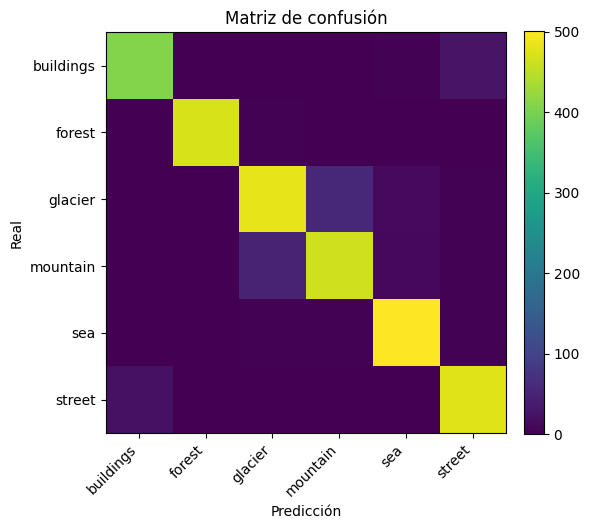

In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Cargar mejor modelo guardado
best = tf.keras.models.load_model(BEST_PATH)

test_loss, test_acc = best.evaluate(test_ds, verbose=0)
print(f"Accuracy en test: {test_acc:.4f}")

# Predicciones en test
y_true, y_pred = [], []
for imgs, labels in test_ds:
    probs = best.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(probs, axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
im = plt.imshow(cm, interpolation='nearest')
plt.title("Matriz de confusión")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### **Curvas de entrenamiento (accuracy y loss)**

Se grafican las curvas de aprendizaje para ambas fases, permitiendo verificar comportamiento del modelo, tendencias de sobre/infraentrenamiento y la eficacia del fine-tuning.

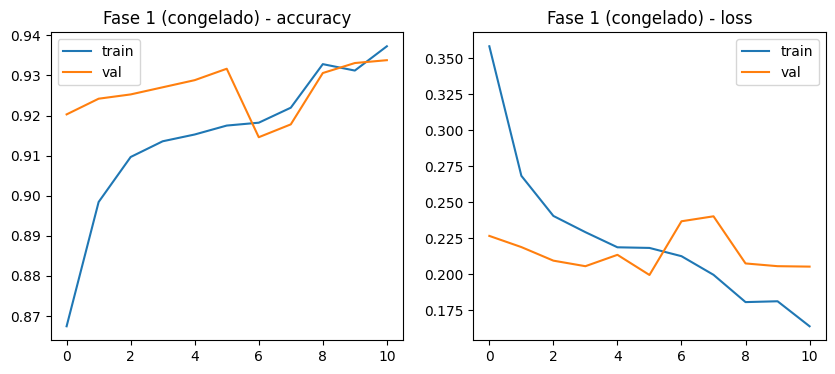

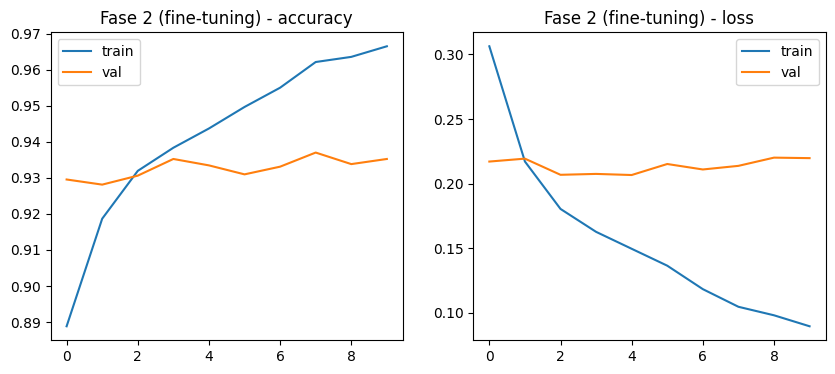

In [23]:
def plot_hist(hist, title_prefix):
    plt.figure(figsize=(10,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='val')
    plt.title(f'{title_prefix} - accuracy')
    plt.legend()
    # Loss
    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title(f'{title_prefix} - loss')
    plt.legend()
    plt.show()

plot_hist(history1, "Fase 1 (congelado)")
plot_hist(history2, "Fase 2 (fine-tuning)")

### **Guardado del modelo final**

Se guarda el mejor modelo en formato ***.keras***. Este archivo permite realizar inferencias posteriores o exportarlo hacia otros entornos sin necesidad de reentrenamiento.

In [24]:
FINAL_PATH = MODELS_DIR / "intel_efficientnet_final.keras"
best.save(FINAL_PATH)
print("Modelo guardado en:", FINAL_PATH)

Modelo guardado en: /content/models/intel_efficientnet_final.keras


### **Inferencia con imagen personalizada**

Se carga una imagen externa, se preprocesa al mismo tamaño del modelo y se realiza la inferencia.
Se muestra la clase predicha, la probabilidad asociada, y la distribución completa de puntuaciones por clase.

***Esta etapa valida la aplicabilidad del modelo frente a imágenes reales no vistas durante el entrenamiento.***

Saving bellas_artes.jpeg to bellas_artes.jpeg


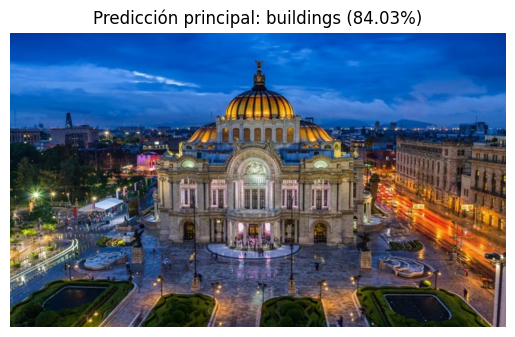

Probabilidades por clase:

buildings   : 84.03%
street      : 15.96%
sea         : 0.01%
glacier     : 0.00%
mountain    : 0.00%
forest      : 0.00%


In [27]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Subir imagen
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Cargar imagen al tamaño esperado
img = image.load_img(img_path, target_size=IMG_SIZE)
x = image.img_to_array(img)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = tf.expand_dims(x, 0)  # batch dimension

# Predicción
pred = best.predict(x, verbose=0)[0]

# Predicción principal
cls = class_names[int(np.argmax(pred))]
conf = float(np.max(pred)) * 100

# Mostrar imagen y resultado principal
plt.imshow(image.load_img(img_path))
plt.axis('off')
plt.title(f"Predicción principal: {cls} ({conf:.2f}%)")
plt.show()

# Mostrar todas las probabilidades
print("Probabilidades por clase:\n")
sorted_idx = np.argsort(pred)[::-1]
for i in sorted_idx:
    print(f"{class_names[i]:<12}: {pred[i]*100:.2f}%")

## **Conclusión Final**
---


En conclusión, la implementación desarrollada demuestra un pipeline completo y robusto para la clasificación automática de escenas utilizando técnicas modernas de deep learning y transfer learning. El uso de EfficientNetB0, junto con un proceso bien estructurado de preprocesamiento, aumento de datos, entrenamiento en dos fases y evaluación detallada, permitió obtener un modelo capaz de generalizar adecuadamente sobre imágenes reales. Además, la integración de un módulo de inferencia facilita la aplicación práctica del modelo en escenarios del mundo real, desde sistemas de análisis visual hasta herramientas de indexación automática. Este proyecto evidencia la efectividad de combinar arquitecturas preentrenadas con un diseño experimental cuidadoso para resolver tareas de clasificación de imágenes de manera eficiente y escalable.